In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = 24   # if monthly --> 12, else if hourly --> 24
FEATURES = 4
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 25 x 24 x 4


In [3]:
import pandas as pd

latitude = 23.8103
longitude = 90.4125

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}"
    f"&longitude={longitude}"
    "&start_date=2025-01-01"
    "&end_date=2025-12-31"
    "&hourly=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m"
)

data = requests.get(url).json()

df = pd.DataFrame(data["hourly"])
df["time"] = pd.to_datetime(df["time"])

df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2025-01-01 00:00:00,15.0,95,0.0,8.9
1,2025-01-01 01:00:00,14.9,97,0.0,8.7
2,2025-01-01 02:00:00,16.1,91,0.0,8.9
3,2025-01-01 03:00:00,17.9,82,0.0,6.7
4,2025-01-01 04:00:00,20.1,73,0.0,7.5


In [4]:
df.shape

(8760, 5)

In [5]:
df.shape, df.dtypes, df.isnull().sum()

((8760, 5),
 time                    datetime64[ns]
 temperature_2m                 float64
 relative_humidity_2m             int64
 precipitation                  float64
 wind_speed_10m                 float64
 dtype: object,
 time                    0
 temperature_2m          0
 relative_humidity_2m    0
 precipitation           0
 wind_speed_10m          0
 dtype: int64)

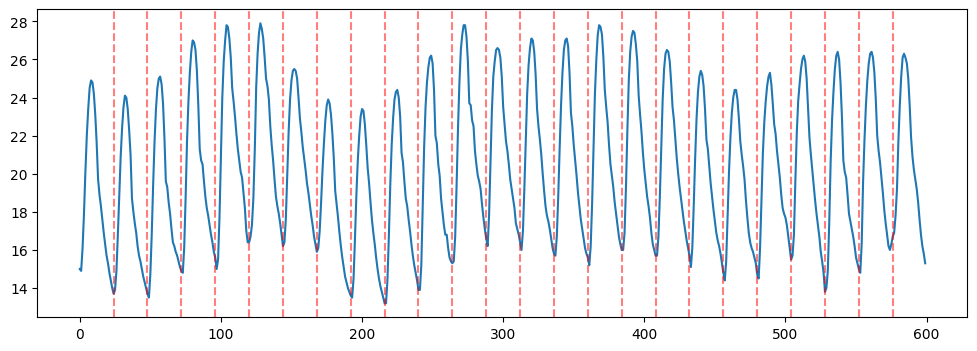

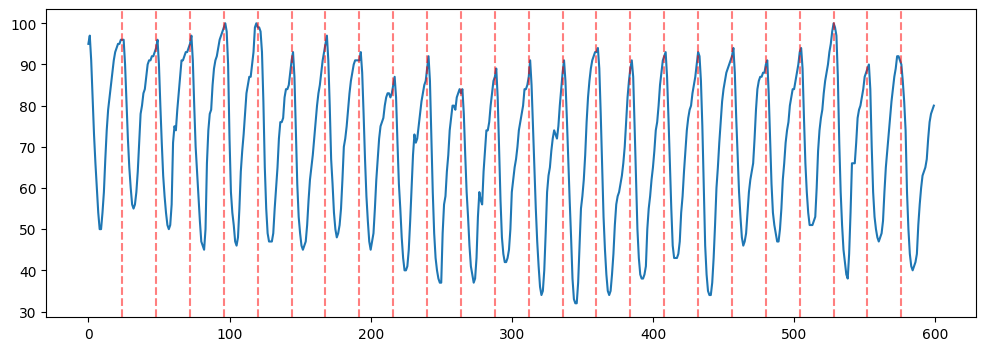

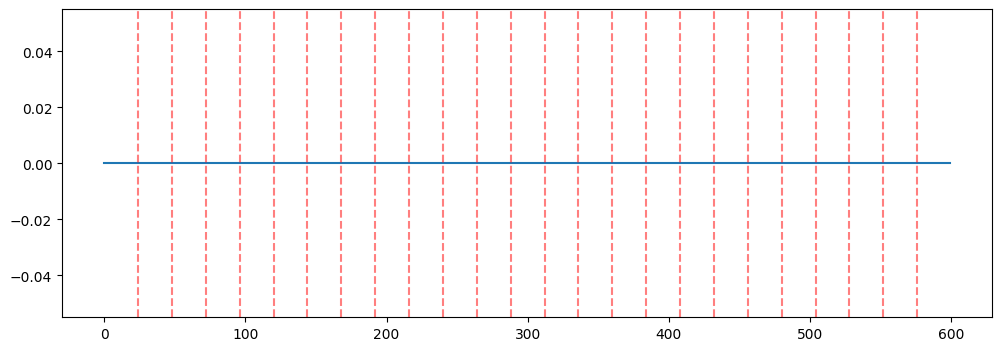

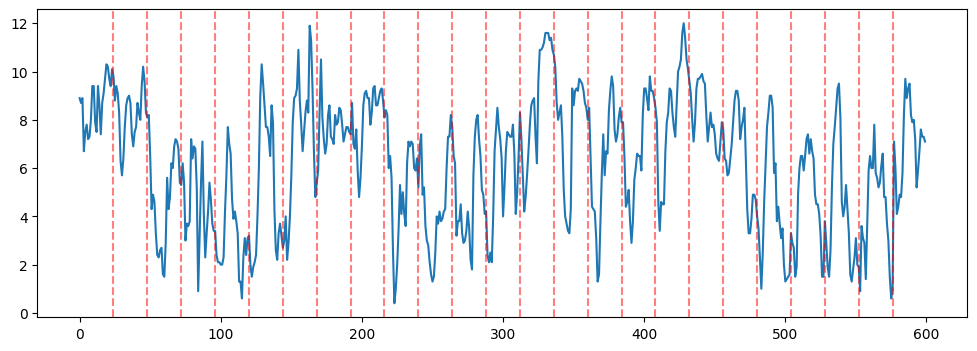

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.to_list()

for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df[col][:PERIOD*TIME].values)
    for i in range(1, PERIOD):
        plt.axvline(x=i*TIME, color='r', linestyle='--', alpha=0.5)


### Smoothing using rolling mean

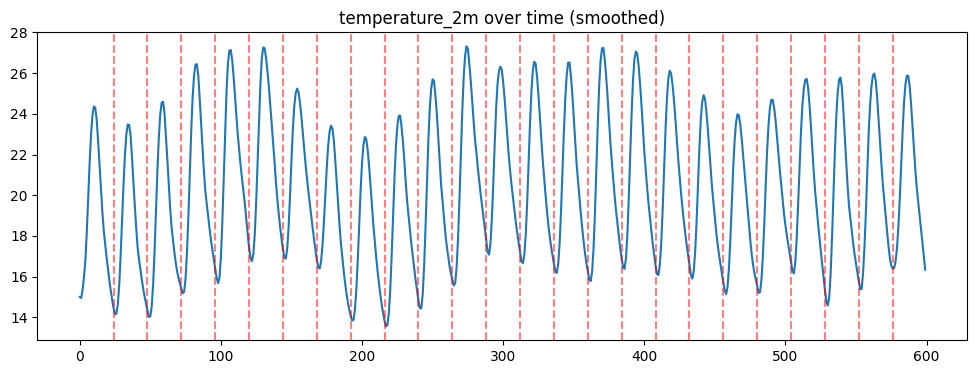

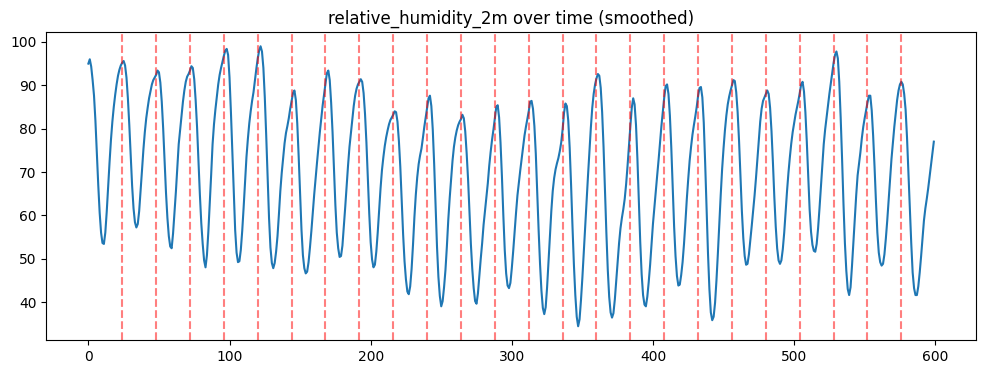

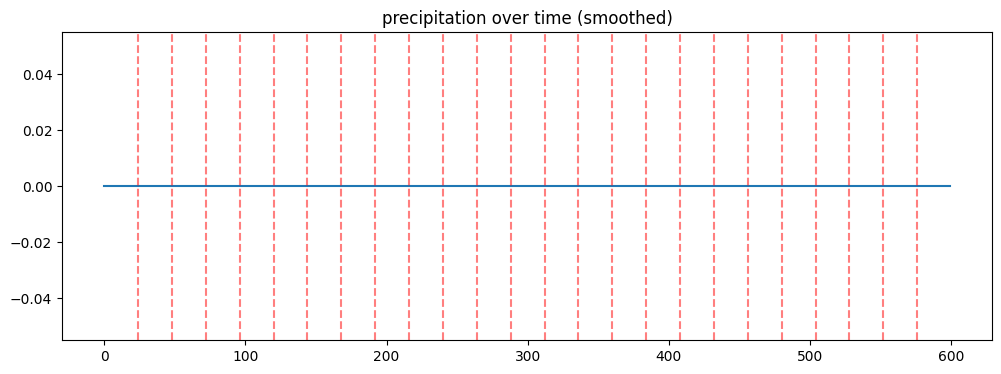

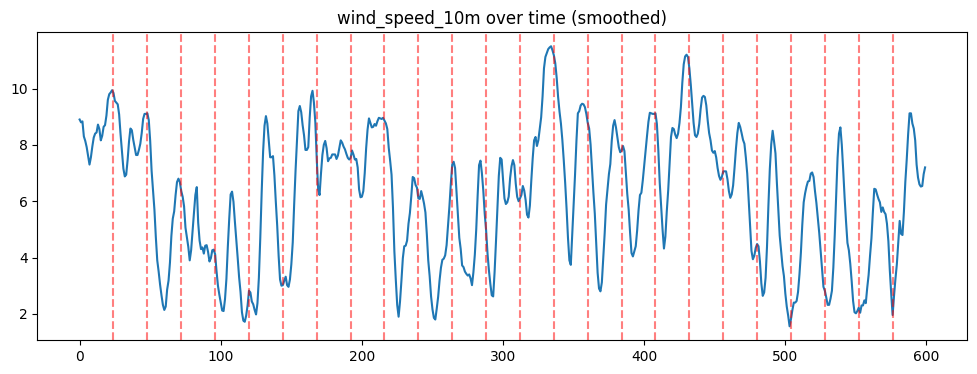

In [7]:
# make each numeric column smooth by rolling mean
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df[col][:PERIOD*TIME])
    for i in range(1, PERIOD):
        plt.axvline(x=i*TIME, color='r', linestyle='--', alpha=0.5)
    plt.title(f"{col} over time (smoothed)")

In [8]:
data = df[numeric_cols][:PERIOD*TIME].values

tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(25, 24, 4)

In [9]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 24, 4)
Test tensor shape: (5, 24, 4)


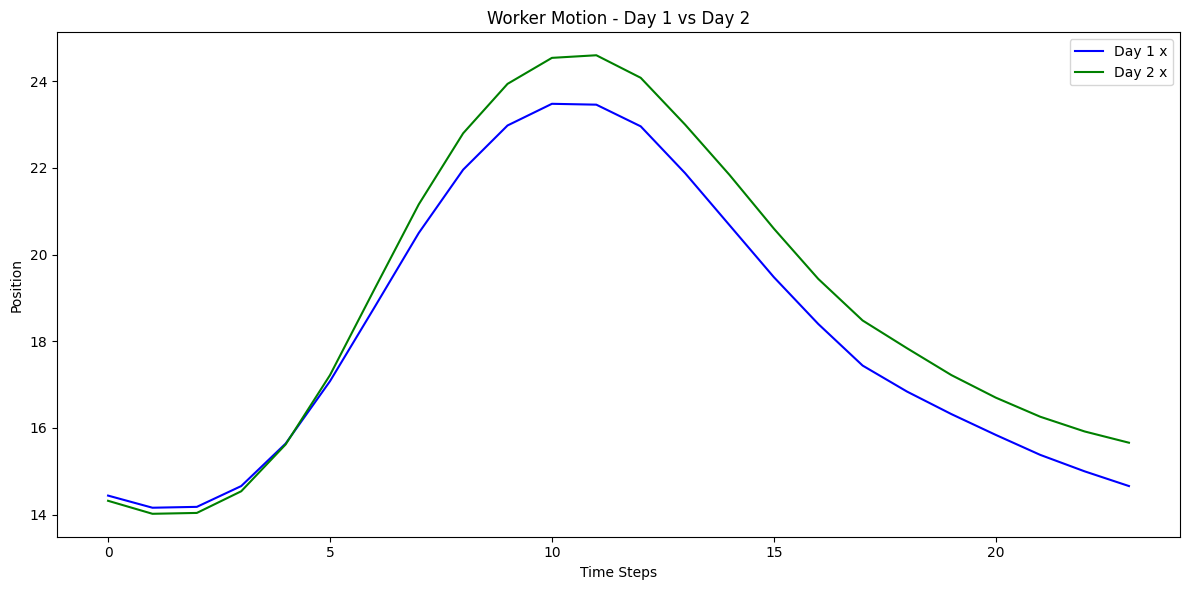

In [10]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [11]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (24, 2)
Feature factors shape: (4, 2)


In [12]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 24, 4)
Reconstructed tensor shape: (20, 24, 4)


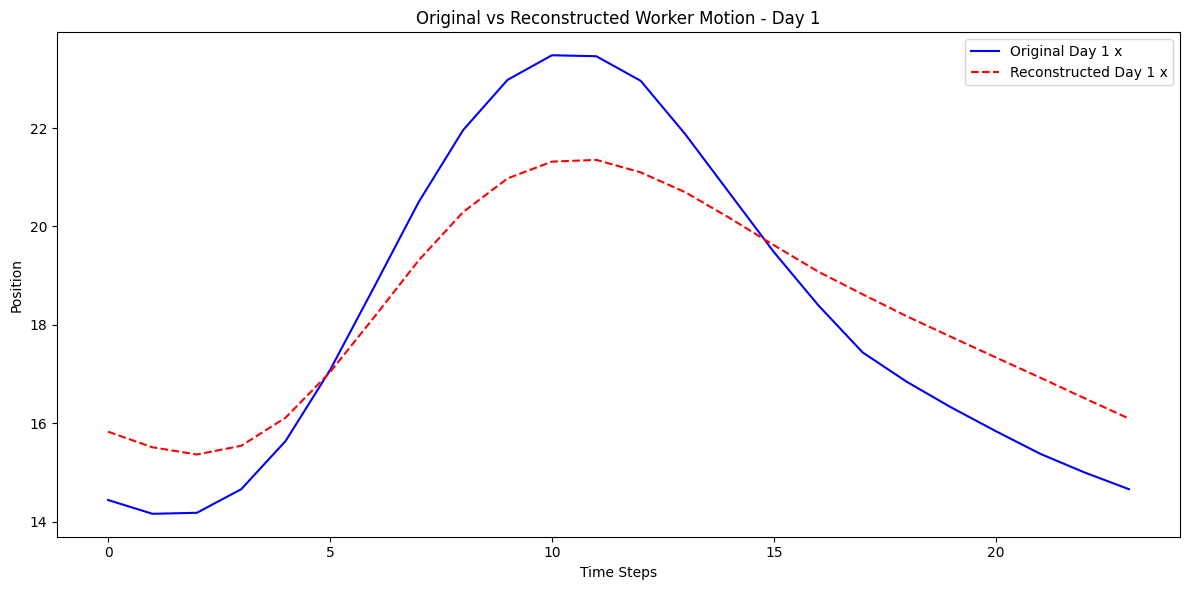

In [13]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [14]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

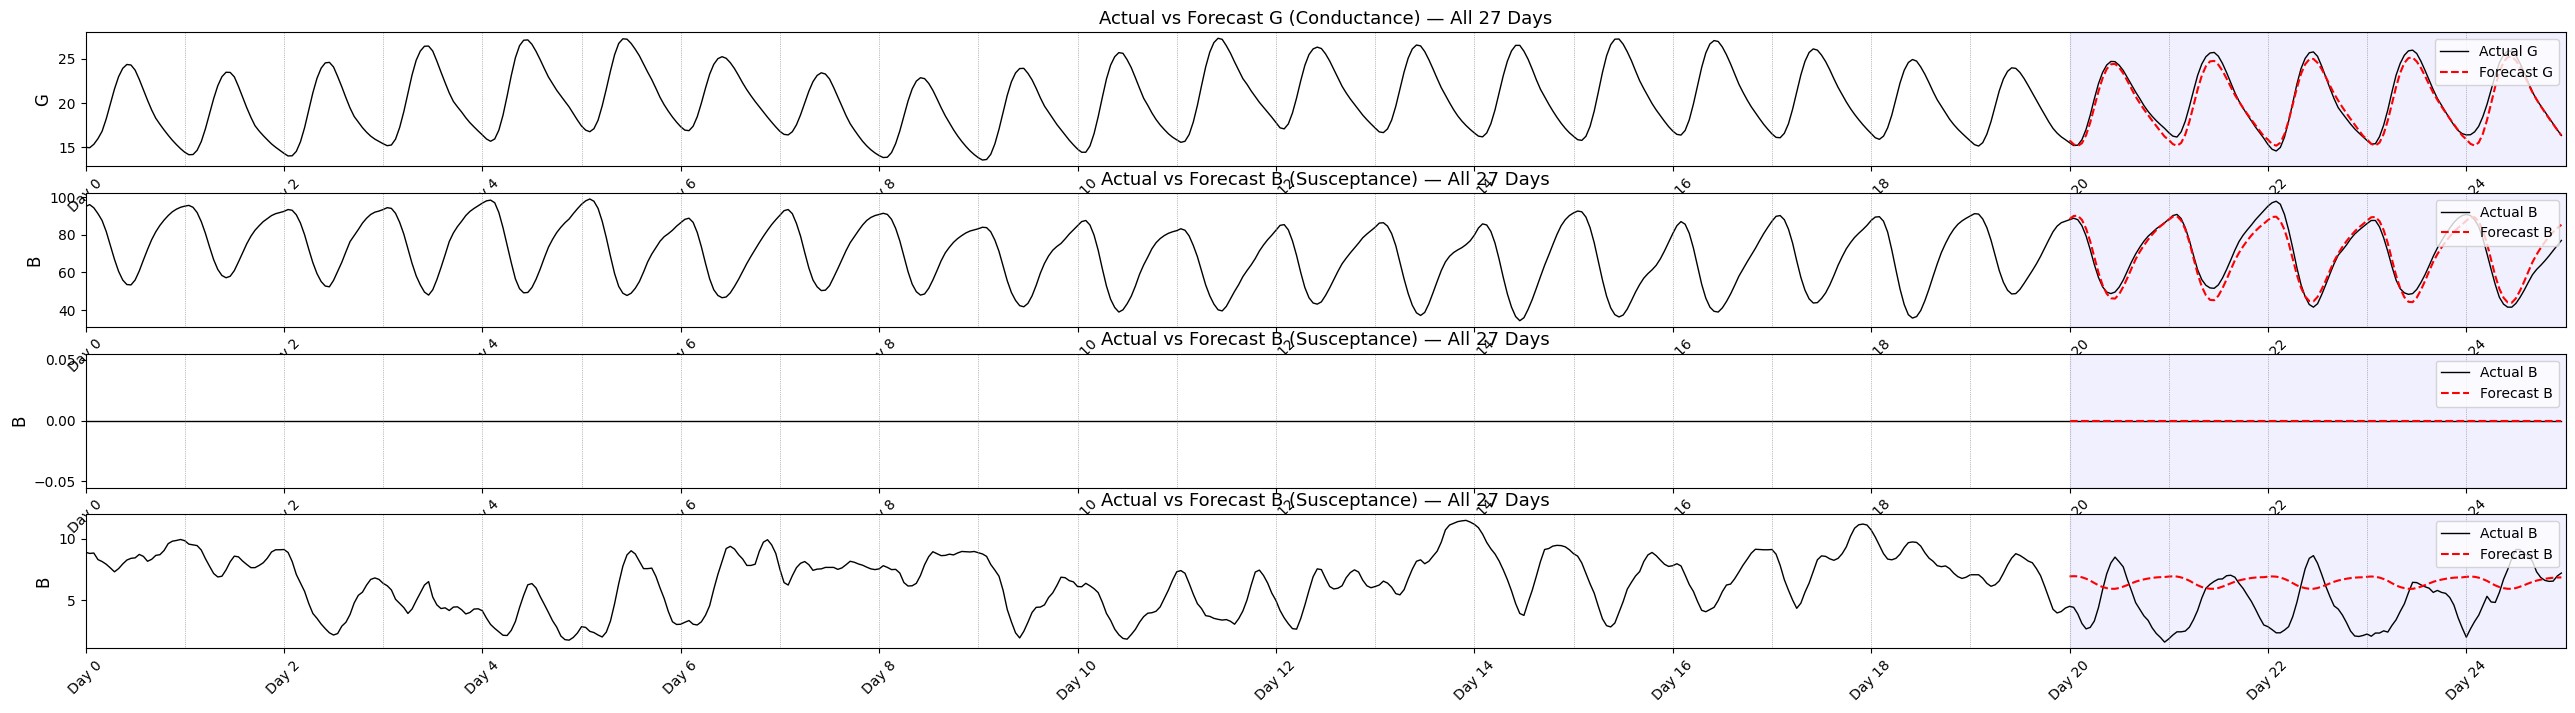

In [15]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

plt.figure(figsize=(32, 8))

plt.subplot(4, 1, 1)
plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('G', fontsize=12)
plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 2)
plt.plot(x, full_series[:, 1], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 3)
plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

plt.subplot(4, 1, 4)
plt.plot(x, full_series[:, 3], 'k-', lw=1, label='Actual B')
plt.plot(x_forecast, forecast_series[:, 3], 'r--', lw=1.5, label='Forecast B')
for d in range(1, PERIOD + 1):
    plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
plt.xticks(np.arange(0, T + 1, 2 * TIME),
           [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
plt.xlim(0, T)
plt.ylabel('B', fontsize=12)
plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
plt.legend(loc='upper right')

# plt.xlabel('Time Steps', fontsize=12)
# plt.tight_layout()
# plt.show()

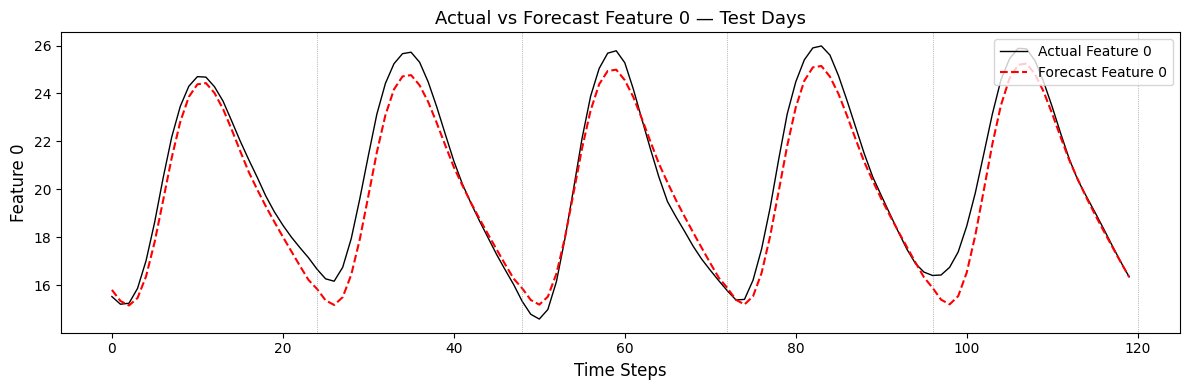

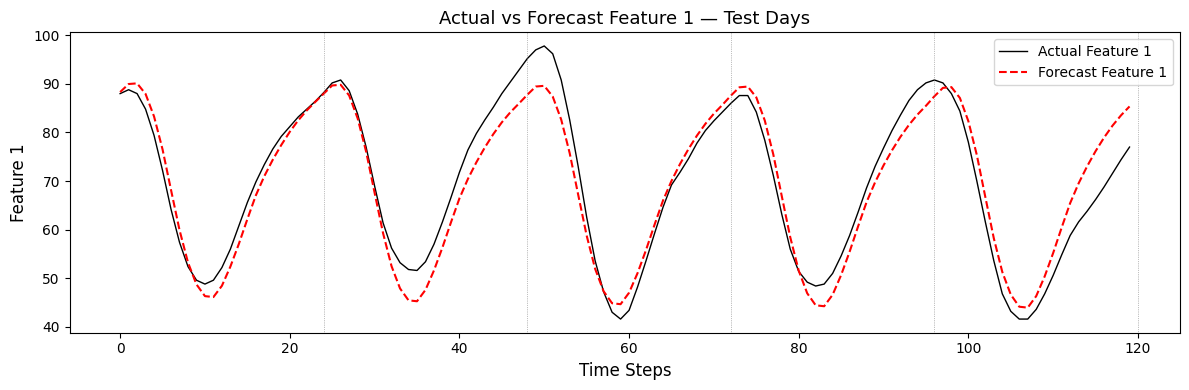

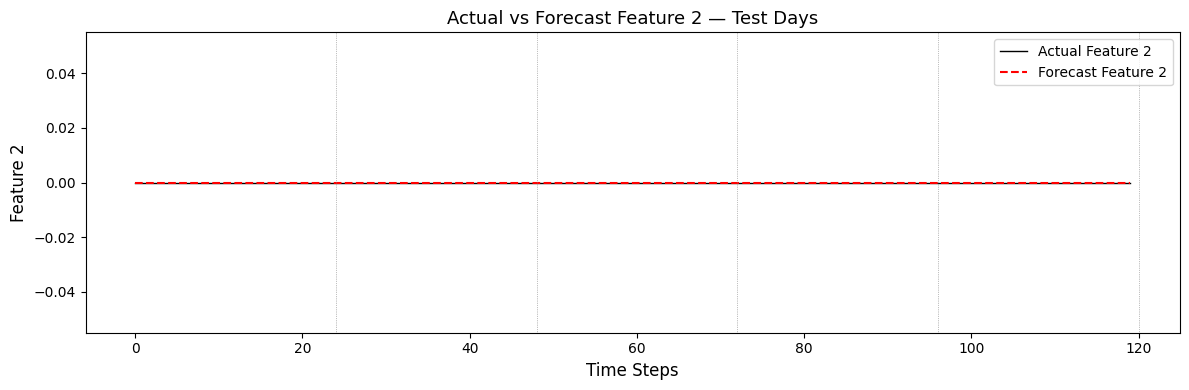

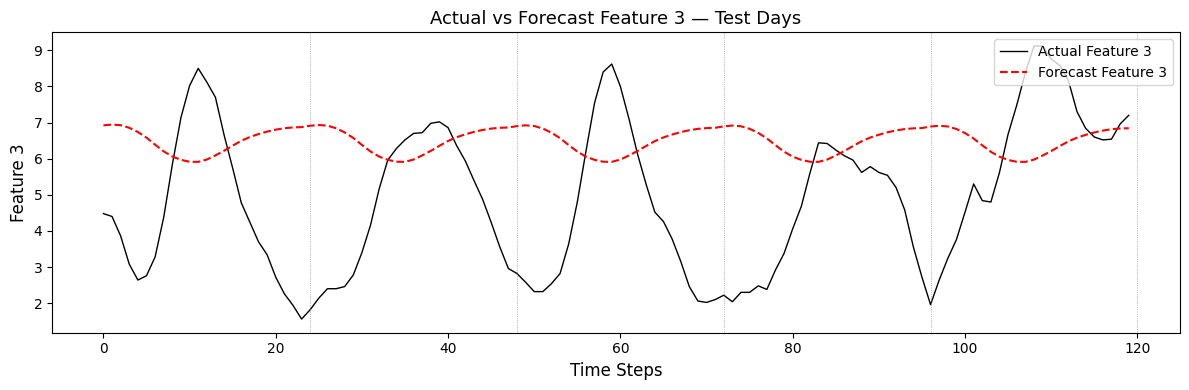

In [16]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [17]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((480, 4), (120, 4))

In [19]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("average R²: {:.4f}, average MSE: {:.4f}, average MAE: {:.4f}, average RMSE: {:.4f}".format(
    np.mean(r2_scores), np.mean(mse_scores), np.mean(mae_scores), np.mean(rmse_scores)))

Feature 0 R²: 0.9525, MSE: 0.5735, MAE: 0.6001, RMSE: 0.7573
Feature 1 R²: 0.9207, MSE: 19.7608, MAE: 3.7431, RMSE: 4.4453
Feature 2 R²: 1.0000, MSE: 0.0000, MAE: 0.0000, RMSE: 0.0000
Feature 3 R²: -0.8852, MSE: 8.0200, MAE: 2.3494, RMSE: 2.8320
average R²: 0.4970, average MSE: 7.0886, average MAE: 1.6731, average RMSE: 2.0086
